#**데이터셋 정의 및 분석**

###Kaggle의 FER-2013 데이터셋
* 데이터 내용
    * 35,900개의 얼굴 표정 이미지
    * 48 x 48 픽셀 (총 2,304픽셀)
    * 표정에 나타난 감정 바탕 7개의 클래스로 분류
        * 0 = Angry, 1 = Disgust, 2 = Fear, 3 = Happy, 4 = Sad, 5 = Surprise, 6 = Neutral
* 데이터 셋 구성 요소
    * 학습용 데이터: 28,709개
    * 테스트용 데이터: 7,178개








##1. 데이터 분석

데이터 셋 가져오기

In [ ]:
# 1. Kaggle 설치
!pip install -q kaggle

# 2. 토큰 저장
!mkdir -p ~/.kaggle
!echo "KAGGLE_API_KEY" > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

# 3. 데이터셋 다운로드
!kaggle datasets download -d msambare/fer2013

# 4. 압축 해제
!unzip -q fer2013.zip -d fer2013

# 5. 폴더 확인
!ls fer2013

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 261MB/s]

test  train


데이터 셋 확인

In [ ]:
# 데이터 개수 확인
import os

# 1. 학습 데이터 이미지 개수 확인
train_count = 0
for category in os.listdir("fer2013/train"):
    category_path = os.path.join("fer2013/train", category)
    train_count += len(os.listdir(category_path))

# 2. 테스트 데이터 이미지 개수 확인
test_count = 0
for category in os.listdir("fer2013/test"):
    category_path = os.path.join("fer2013/test", category)
    test_count += len(os.listdir(category_path))

# 3. 카테고리 별 이미지 개수 확인
categories = sorted(os.listdir("fer2013/train"))
counts = []
for category in categories:
    path = os.path.join("fer2013/train", category)
    counts.append(len(os.listdir(path)))

# 4. 출력하기
print(f'학습셋 이미지 수: {train_count}개')
print(f'테스트셋 이미지 수: {test_count}개')
print("카테고리별 이미지 수")
for category, count in zip (categories, counts):
    print(f'- {category}: {count}개')


학습셋 이미지 수: 28709개
테스트셋 이미지 수: 7178개
카테고리별 이미지 수
- angry: 3995개
- disgust: 436개
- fear: 4097개
- happy: 7215개
- neutral: 4965개
- sad: 4830개
- surprise: 3171개


클래스 이미지 분포

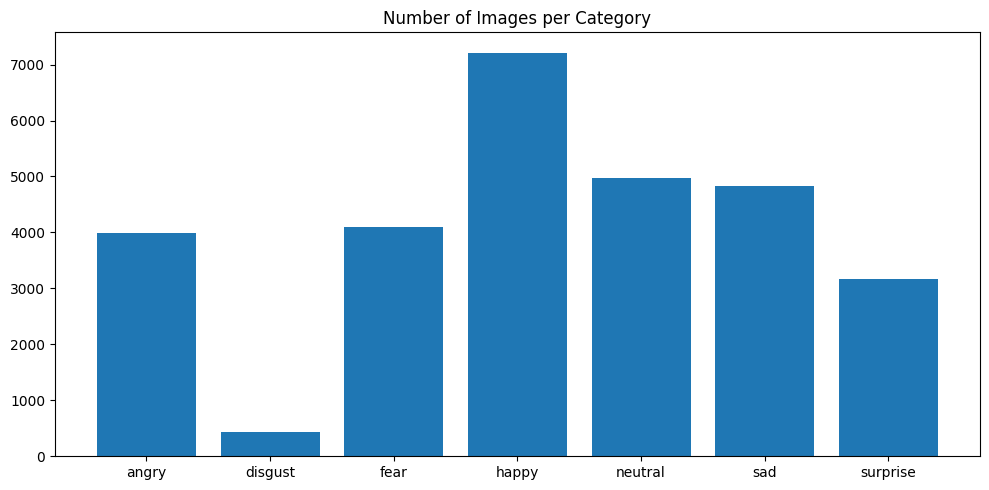

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(categories, counts)
plt.title('Number of Images per Category')
plt.tight_layout()
plt.show()

샘플 이미지 시각화

(48, 48)


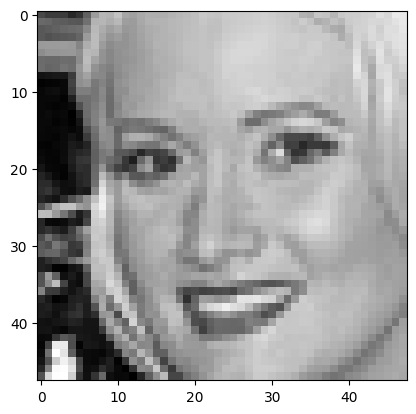

In [ ]:
# 첫번째 이미지 확인
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

happy_folder = "fer2013/train/happy"

first_file = os.listdir(happy_folder)[0]

img = Image.open(os.path.join(happy_folder, first_file))

print(img.size)
plt.imshow(img, cmap='gray')
plt.show()

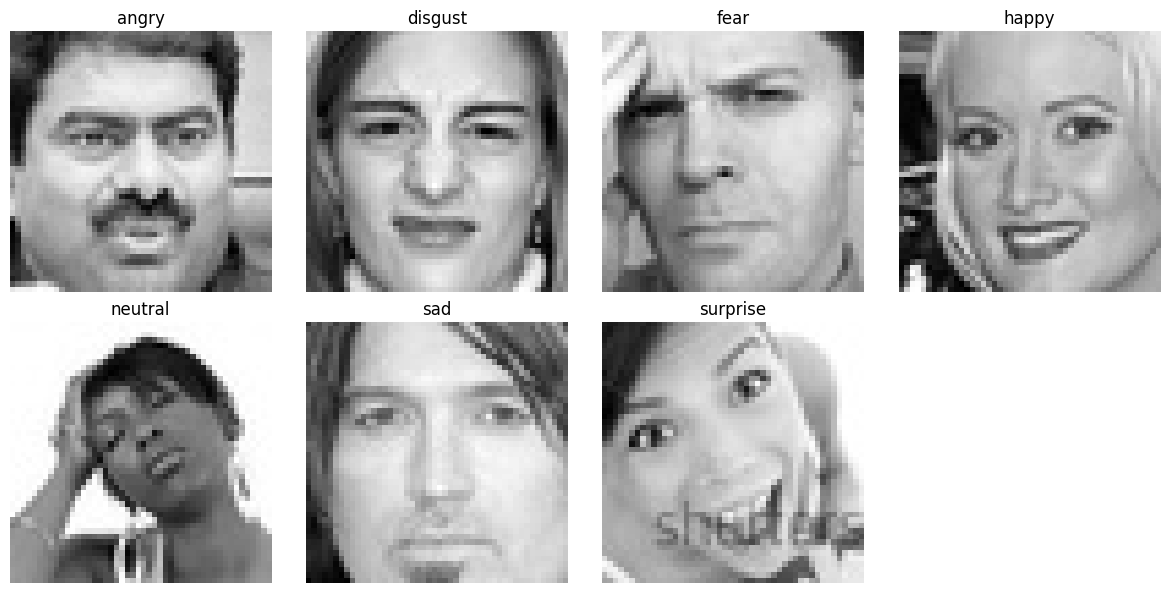

In [ ]:
# 각 카테고리별 사진
plt.figure(figsize=(12,6))

for i, category in enumerate(categories):
    folder = os.path.join("fer2013/train", category)

    file = os.listdir(folder)[0]

    img = Image.open(os.path.join(folder, file))

    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(category)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 2. 데이터 분리

### 라이브러리 임포트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.utils import shuffle

import matplotlib.pyplot as plt
import numpy as np

### 학습셋과 테스트셋 나누기

In [ ]:
# 1. train, test 리스트 생성
X_train = []
Y_train = []

X_test = []
Y_test = []

# 2. 각 폴더 읽기
train_dir = "fer2013/train"
test_dir = "fer2013/test"

# 3. train 리스트에 저장
for label, category in enumerate(categories):
    folder = os.path.join(train_dir, category)
    for file in os.listdir(folder):
        img = Image.open(os.path.join(folder, file))
        img_array = np.array(img)
        X_train.append(img_array)
        Y_train.append(label)

# test 리스트에 저장
for label, category in enumerate(categories):
    folder = os.path.join(test_dir, category)
    for file in os.listdir(folder):
        img = Image.open(os.path.join(folder, file))
        img_array = np.array(img)
        X_test.append(img_array)
        Y_test.append(label)

# 4. numpy 배열로 변환
X_train = np.array(X_train)
Y_train = np.array(Y_train)

X_test = np.array(X_test)
Y_test = np.array(Y_test)

# 5. 데이터 섞기
X_train, Y_train = shuffle(X_train, Y_train, random_state = 42)
X_test, Y_test = shuffle(X_test, Y_test, random_state = 42)

# 6. 데이터 크기 맞추기
X_train = X_train.reshape(X_train.shape[0], 48, 48, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 48, 48, 1).astype('float32') / 255
Y_train = to_categorical(Y_train, 7)
Y_test = to_categorical(Y_test, 7)

In [ ]:
print(f"데이터: 학습용 {X_train.shape[0]}개, 테스트용 {X_test.shape[0]}개")
print("학습 데이터 형태:", X_train.shape)
print("이미지 1장의 형태:", X_train[0].shape)
print("학습 데이터 라벨 형태:", Y_train.shape)

데이터: 학습용 28709개, 테스트용 7178개
학습 데이터 형태: (28709, 48, 48, 1)
이미지 1장의 형태: (48, 48, 1)
학습 데이터 라벨 형태: (28709, 7)


In [ ]:
labels = np.argmax(Y_train, axis=1)

print(labels[:20])
print(labels[-20:])

[2 3 6 2 6 2 0 5 0 4 3 5 4 3 2 4 5 6 0 6]
[0 0 2 4 6 3 6 3 5 1 4 2 5 3 3 5 2 0 4 5]


#**모델 설계 및 실험 결과**

##**1. 기본 CNN 모델**

###CNN 모델 설계
* 구성
    * Convolution Layer(32, 64)
    * Pooling Layer(MaxPooling)
    * Dropout
    * Dense Layer(0.25)
    * Softmax 출력층 사용

* 하이퍼파라미터
    * Optimizer: Adam
    * Learning Rate: 0.001 (Adam 내 기본 설정된 Learning Rate 값)
    * Batch size: 64
    * Epoch: 10







###**(1) 기본 CNN 모델 구조 설정**

In [ ]:
# 모델 저장 경로 설정 (구글 드라이브 내 경로)
First_CNN_modelpath = "/content/drive/MyDrive/FER2013_First_CNN.keras"

# 이어하기 : 기존 파일 존재 여부에 따라 결정
if os.path.exists(First_CNN_modelpath):
    print("\n[알림] 구글 드라이브에서 기존에 학습된 모델을 불러옵니다.")
    First_CNN_model = load_model(First_CNN_modelpath)
else:
    print("\n[알림] 기존 모델이 없으므로 새로운 모델을 생성합니다.")
    First_CNN_model = Sequential()
    First_CNN_model.add(Conv2D(32, kernel_size= (3, 3), padding='same', input_shape = (48,48,1), activation='relu'))
    First_CNN_model.add(Conv2D(64, (3, 3), activation='relu'))
    First_CNN_model.add(MaxPooling2D(pool_size=(2, 2)))
    First_CNN_model.add(Dropout(0.25))
    First_CNN_model.add(Flatten())

    First_CNN_model.add(Dense(128, activation='relu'))
    First_CNN_model.add(Dropout(0.5))
    First_CNN_model.add(Dense(7, activation='softmax'))

    First_CNN_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


[알림] 기존 모델이 없으므로 새로운 모델을 생성합니다.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 최적화 및 조기 종료 설정
# 여기서도 filepath를 드라이브 경로(modelpath)로 지정.
checkpointer = ModelCheckpoint(filepath=First_CNN_modelpath, monitor='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10)

# 모델 학습 실행
print("\n학습을 시작합니다...")
history = First_CNN_model.fit(X_train, Y_train, validation_split=0.2,
                    epochs=10, batch_size=64, verbose=1,
                    callbacks=[early_stopping_callback, checkpointer])

# 최종 테스트 정확도 출력
print("\n--- 학습 완료 ---")
score = First_CNN_model.evaluate(X_test, Y_test, verbose=0)
print("최종 테스트 정확도: %.4f" % score[1])


학습을 시작합니다...
Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2493 - loss: 1.8467
Epoch 1: val_loss improved from None to 1.59784, saving model to /content/drive/MyDrive/FER2013_First_CNN.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FER2013_First_CNN.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.2910 - loss: 1.7552 - val_accuracy: 0.3805 - val_loss: 1.5978
Epoch 2/10
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3761 - loss: 1.5927
Epoch 2: val_loss improved from 1.59784 to 1.50389, saving model to /content/drive/MyDrive/FER2013_First_CNN.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FER2013_First_CNN.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3818 - loss: 1.5796 - val_accuracy: 0.4338 - val_loss: 1.5039
Epoch 3/10
358/359 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4225 - loss: 1.5039
Epoch 3: val_loss improved from 1.50389 to 1.41743, saving model to /content/drive/MyDrive/FER201

###**(2) 학습 과정 모니터링**

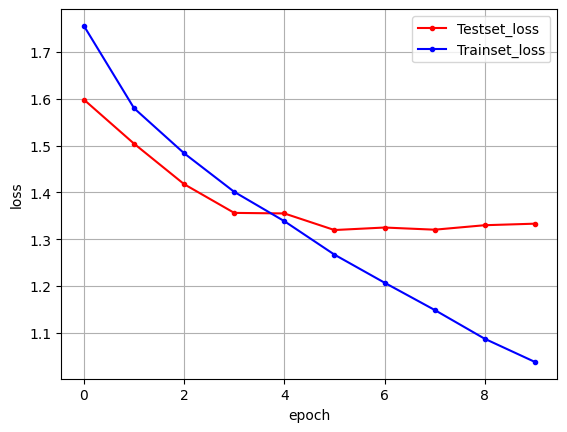

In [ ]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

###**(3) 성능 평가 및 오류 분석**

In [ ]:
First_CNN_predictions = First_CNN_model.predict(X_test)
First_CNN_predicted_labels = np.argmax(First_CNN_predictions, axis=1)

First_CNN_true_labels = np.argmax(Y_test, axis=1)

print(First_CNN_predictions)
print(First_CNN_predicted_labels)
print(First_CNN_true_labels)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[[3.1455487e-02 1.4850710e-03 2.3484637e-01 ... 2.1126485e-01
  2.5865024e-01 1.4949240e-02]
 [1.4774009e-02 6.4048249e-06 5.0531225e-03 ... 8.5831424e-03
  6.0444199e-03 3.7631206e-04]
 [4.3639969e-02 4.5460318e-03 2.7036989e-02 ... 8.0709738e-01
  1.9165829e-02 2.1654427e-02]
 ...
 [1.5420623e-03 6.0912166e-06 4.5983681e-01 ... 2.1085909e-02
  3.5323054e-01 7.1528792e-02]
 [1.6368560e-01 9.2406599e-06 5.4664582e-02 ... 1.5156542e-01
  3.3795261e-01 6.0718937e-04]
 [1.5016389e-01 3.2244748e-03 8.0382004e-02 ... 1.7419414e-01
  2.0436710e-01 6.2856518e-02]]
[5 3 4 ... 2 5 3]
[4 3 4 ... 5 5 0]


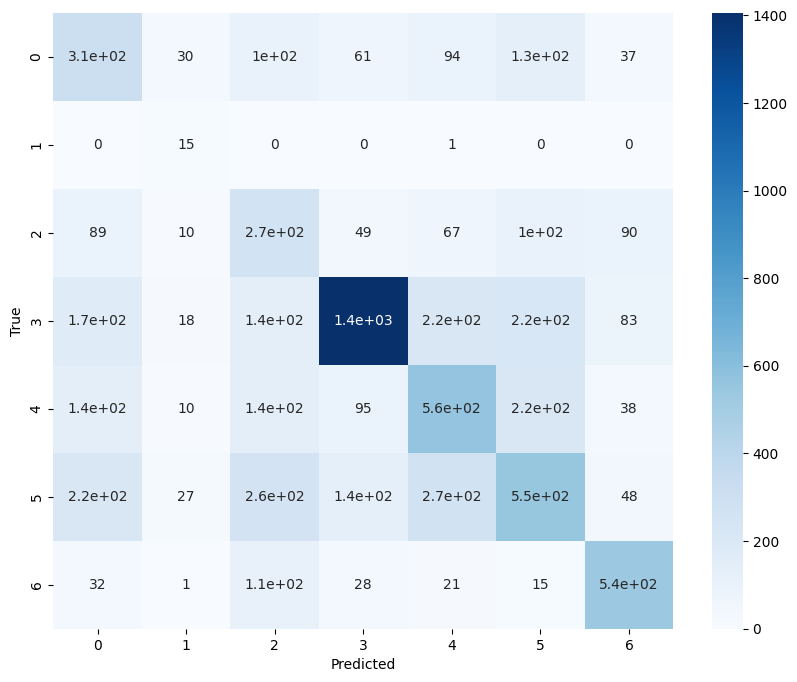

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(First_CNN_predicted_labels, First_CNN_true_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
from sklearn.metrics import f1_score


# Macro 평균
f1_macro = f1_score(First_CNN_true_labels, First_CNN_predicted_labels, average='macro')
print(f"First_CNN_Macro F1 Score: {f1_macro:.4f}")

# Weighted 평균
f1_weighted = f1_score(First_CNN_true_labels, First_CNN_predicted_labels, average='weighted')
print(f"First_CNN_Weighted F1 Score: {f1_weighted:.4f}")


First_CNN_Macro F1 Score: 0.4503
First_CNN_Weighted F1 Score: 0.4970


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

cr = classification_report(First_CNN_true_labels, First_CNN_predicted_labels, target_names = categories)
cr

'              precision    recall  f1-score   support\n\n       angry       0.40      0.32      0.36       958\n     disgust       0.94      0.14      0.24       111\n        fear       0.40      0.26      0.32      1024\n       happy       0.62      0.79      0.70      1774\n     neutral       0.47      0.46      0.46      1233\n         sad       0.37      0.44      0.40      1247\n    surprise       0.72      0.64      0.68       831\n\n    accuracy                           0.51      7178\n   macro avg       0.56      0.44      0.45      7178\nweighted avg       0.51      0.51      0.50      7178\n'

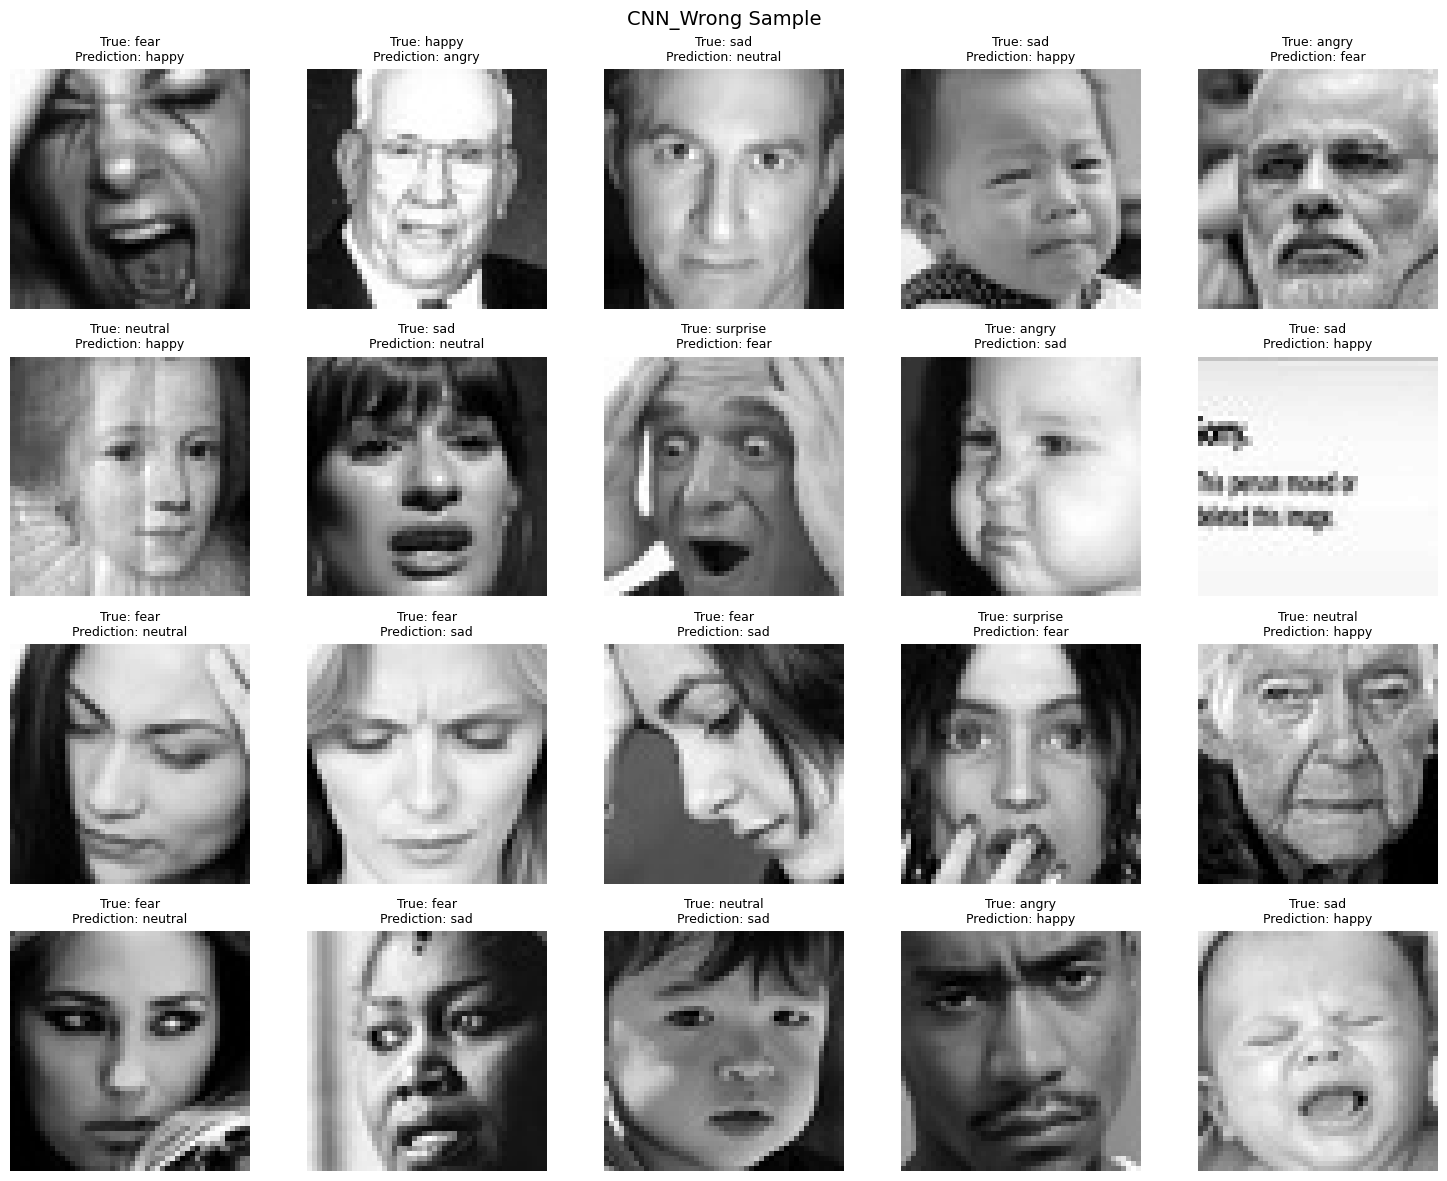

In [ ]:
emotion_labels = categories

# 틀린 인덱스 추출
wrong_idx = np.where(First_CNN_predicted_labels != First_CNN_true_labels)[0]

# 20개만 랜덤 샘플
sample_idx = np.random.choice(wrong_idx, size=20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i, idx in enumerate(sample_idx):
    axes[i].imshow(X_test[idx].reshape(48, 48), cmap='gray')
    axes[i].set_title(
        f"True: {emotion_labels[First_CNN_true_labels[idx]]}\nPrediction: {emotion_labels[First_CNN_predicted_labels[idx]]}",
        fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('CNN_Wrong Sample', fontsize=14)
plt.tight_layout()
plt.show()

##**2. 개선된 CNN 모델**

###CNN 모델 설계
* 구성
    * Convolution Layer 4개(32, 64)
    * Global Average Pooling
    * Dropout
    * Dense Layer: 512
    * Softmax 출력층

* 하이퍼파라미터
    * Optimizer: Adam
    * Learning Rate: 0.001 (Adam 내 기본 설정된 Learning Rate 값)
    * Batch size: 64
    * Epoch: 10







### **(1) 개선된 CNN 모델 구조 설정**

In [ ]:
# 모델 저장 경로 설정 (구글 드라이브 내 경로)
CNN_modelpath = "/content/drive/MyDrive/FER2013_CNN.keras"

# 이어하기 : 기존 파일 존재 여부에 따라 결정
if os.path.exists(CNN_modelpath):
    print("\n[알림] 구글 드라이브에서 기존에 학습된 모델을 불러옵니다.")
    CNN_model = load_model(CNN_modelpath)
else:
    print("\n[알림] 기존 모델이 없으므로 새로운 모델을 생성합니다.")
    CNN_model = Sequential()
    CNN_model.add(Conv2D(32, kernel_size= (3, 3), padding='same', input_shape=(48, 48, 1), activation='relu'))
    CNN_model.add(Conv2D(32, (3, 3), activation='relu'))
    CNN_model.add(MaxPooling2D(pool_size=(2, 2)))
    CNN_model.add(Dropout(0.25))

    CNN_model.add(Conv2D(64, (3,3), padding='same', activation = 'relu'))
    CNN_model.add(Conv2D(64, (3,3), activation='relu'))
    CNN_model.add(MaxPooling2D(pool_size=(2,2)))
    CNN_model.add(Dropout(0.25))

    CNN_model.add(GlobalAveragePooling2D())
    CNN_model.add(Dense(512, activation='relu'))
    CNN_model.add(Dropout(0.5))
    CNN_model.add(Dense(7, activation='softmax'))

    CNN_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


[알림] 구글 드라이브에서 기존에 학습된 모델을 불러옵니다.


In [ ]:
# 최적화 및 조기 종료 설정
# 여기서도 filepath를 드라이브 경로(modelpath)로 지정.
checkpointer = ModelCheckpoint(filepath=CNN_modelpath, monitor='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=3)

# 모델 학습 실행
print("\n학습을 시작합니다...")
history = CNN_model.fit(X_train, Y_train, validation_split=0.2,
                    epochs=10, batch_size=64, verbose=1,
                    callbacks=[early_stopping_callback, checkpointer])

# 최종 테스트 정확도 출력
print("\n--- 학습 완료 ---")
score = CNN_model.evaluate(X_test, Y_test, verbose=0)
print("최종 테스트 정확도: %.4f" % score[1])


학습을 시작합니다...
Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5125 - loss: 1.2645
Epoch 1: val_loss improved from None to 1.25354, saving model to /content/drive/MyDrive/FER2013_CNN.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FER2013_CNN.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.5123 - loss: 1.2718 - val_accuracy: 0.5275 - val_loss: 1.2535
Epoch 2/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5192 - loss: 1.2571
Epoch 2: val_loss improved from 1.25354 to 1.23313, saving model to /content/drive/MyDrive/FER2013_CNN.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FER2013_CNN.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5231 - loss: 1.2550 - val_accuracy: 0.5366 - val_loss: 1.2331
Epoch 3/10
354/359 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5310 - loss: 1.2340
Epoch 3: val_loss improved from 1.23313 to 1.23040, saving model to /content/drive/MyDrive/FER2013_CNN.keras

Epoch 3: fin

In [ ]:
CNN_model = load_model(CNN_modelpath)

# 현재 저장된 모델 상태 확인
score = model.evaluate(X_test, Y_test, verbose=0)
print("테스트 정확도: %.4f" % score[1])


테스트 정확도: 0.5599


###**(2) 학습 과정 모니터링**

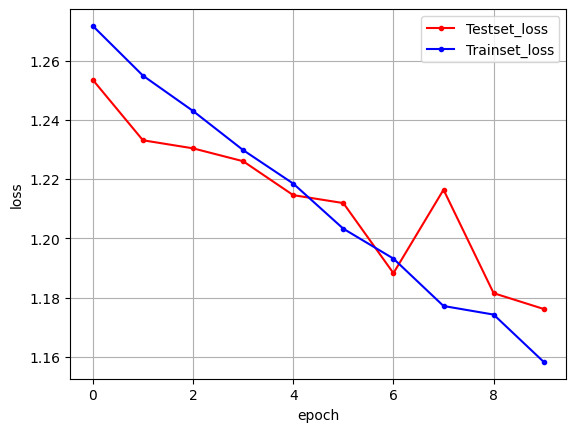

In [ ]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

###**(3) 성능 평가 및 오류 분석**

In [ ]:
CNN_predictions = CNN_model.predict(X_test)
CNN_predicted_labels = np.argmax(CNN_predictions, axis=1)

CNN_true_labels = np.argmax(Y_test, axis=1)

print(CNN_predictions)
print(CNN_predicted_labels)
print(CNN_true_labels)

225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
[[1.1799676e-01 2.0263158e-03 7.4043460e-02 ... 5.1696485e-01
  2.7330005e-01 3.1282953e-03]
 [1.0226743e-03 4.1324656e-05 2.5999596e-04 ... 2.8390909e-02
  5.4344027e-03 1.6899442e-04]
 [4.8052143e-02 1.3746826e-03 5.0137430e-02 ... 7.8867424e-01
  1.0766945e-01 2.5402813e-03]
 ...
 [1.5049972e-01 5.4174191e-03 4.8617572e-01 ... 7.5491339e-02
  1.4850469e-01 7.4702039e-02]
 [8.3719052e-02 5.1473025e-03 2.0314443e-01 ... 1.1533066e-01
  5.6099641e-01 5.5834232e-03]
 [5.7757042e-02 7.2917361e-03 1.9840303e-01 ... 1.5741374e-02
  7.0191425e-01 8.2857476e-04]]
[4 3 4 ... 2 5 5]
[4 3 4 ... 5 5 0]


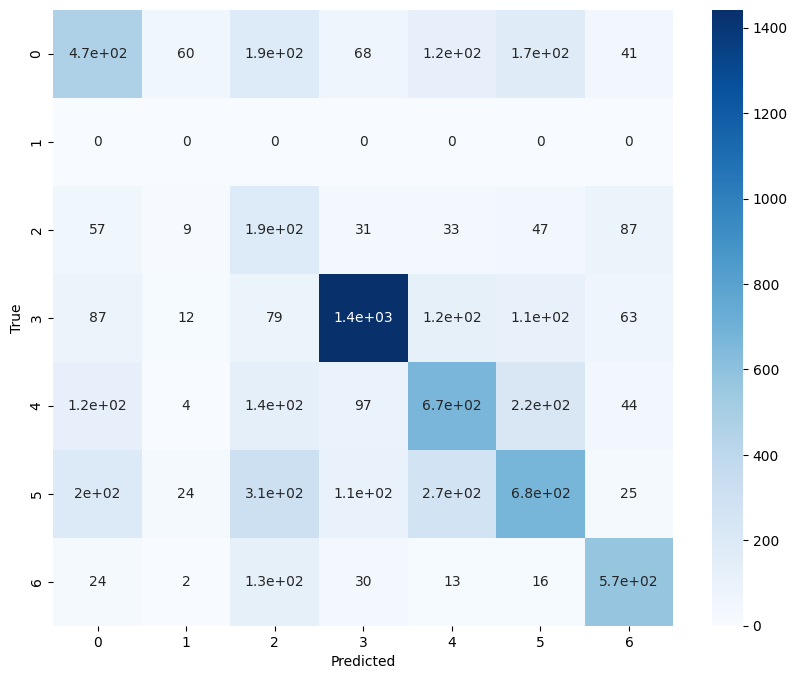

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(CNN_predicted_labels, CNN_true_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
from sklearn.metrics import f1_score


# Macro 평균
f1_macro = f1_score(CNN_true_labels, CNN_predicted_labels, average='macro')
print(f"CNN_Macro F1 Score: {f1_macro:.4f}")

# Weighted 평균
f1_weighted = f1_score(CNN_true_labels, CNN_predicted_labels, average='weighted')
print(f"CNN_Weighted F1 Score: {f1_weighted:.4f}")


CNN_Macro F1 Score: 0.4573
CNN_Weighted F1 Score: 0.5453


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

cr = classification_report(CNN_true_labels, CNN_predicted_labels, target_names = categories)
cr

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'              precision    recall  f1-score   support\n\n       angry       0.42      0.49      0.45       958\n     disgust       0.00      0.00      0.00       111\n        fear       0.42      0.18      0.26      1024\n       happy       0.75      0.81      0.78      1774\n     neutral       0.52      0.54      0.53      1233\n         sad       0.42      0.54      0.47      1247\n    surprise       0.73      0.69      0.71       831\n\n    accuracy                           0.56      7178\n   macro avg       0.47      0.47      0.46      7178\nweighted avg       0.55      0.56      0.55      7178\n'

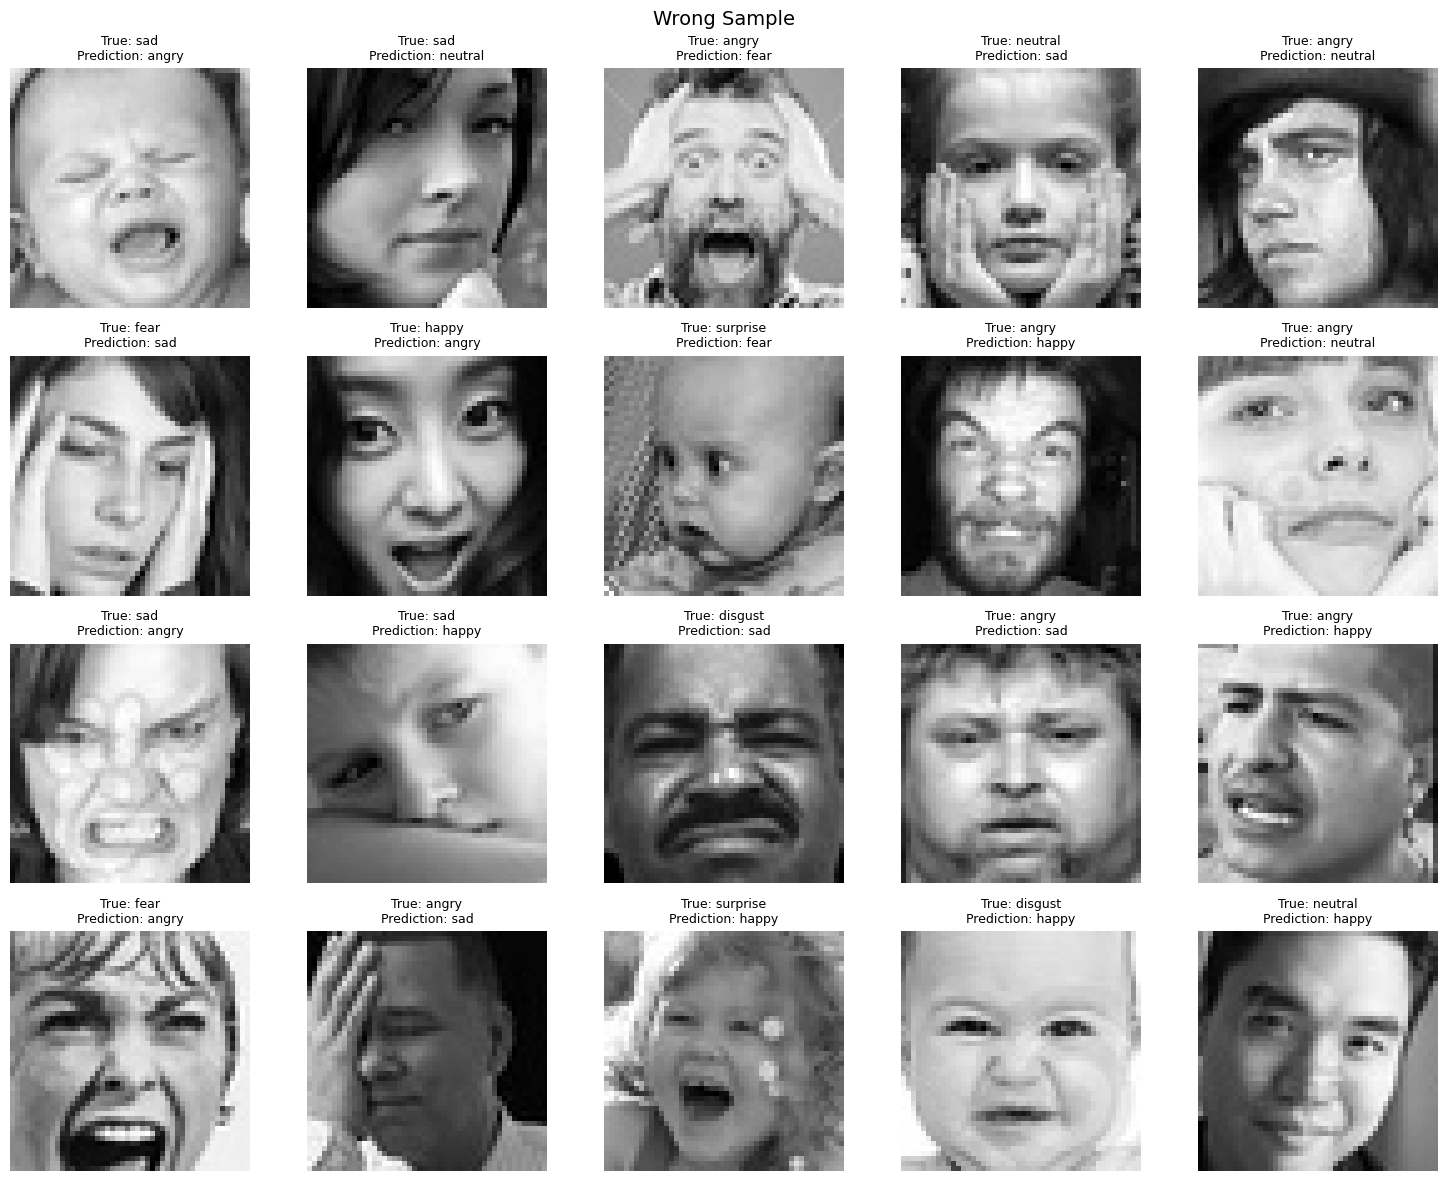

In [ ]:
emotion_labels = categories

# 틀린 인덱스 추출
wrong_idx = np.where(CNN_predicted_labels != CNN_true_labels)[0]

# 20개만 랜덤 샘플
sample_idx = np.random.choice(wrong_idx, size=20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i, idx in enumerate(sample_idx):
    axes[i].imshow(X_test[idx].reshape(48, 48), cmap='gray')
    axes[i].set_title(
        f"True: {emotion_labels[CNN_true_labels[idx]]}\nPrediction: {emotion_labels[CNN_predicted_labels[idx]]}",
        fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('CNN_Wrong Sample', fontsize=14)
plt.tight_layout()
plt.show()

##**3. Class weight된 CNN 모델**

### Sklearn 가중치 부여 모델 설계

In [ ]:
# Sklearn을 사용하여 class별 weight 부여
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight = "balanced", classes = np.unique(CNN_true_labels), y = CNN_true_labels)
class_weight_dict = dict(enumerate(class_weights))

print(class_weights)
print(class_weight_dict)

[1.07038473 9.23809524 1.00139509 0.57803189 0.83165334 0.82231642
 1.2339694 ]
{0: np.float64(1.0703847300924545), 1: np.float64(9.238095238095237), 2: np.float64(1.0013950892857142), 3: np.float64(0.5780318891931068), 4: np.float64(0.8316533426022477), 5: np.float64(0.8223164165425593), 6: np.float64(1.233969400034382)}


In [ ]:
# 모델 저장 경로 설정 (구글 드라이브 내 경로)
class_weight_modelpath = "/content/drive/MyDrive/FER2013_CNN_class_weight.keras"

# 이어하기 : 기존 파일 존재 여부에 따라 결정
if os.path.exists(class_weight_modelpath):
    print("\n[알림] 구글 드라이브에서 기존에 학습된 모델을 불러옵니다.")
    class_weight_model = load_model(class_weight_modelpath)
else:
    print("\n[알림] 기존 모델이 없으므로 새로운 모델을 생성합니다.")
    class_weight_model = Sequential()
    class_weight_model.add(Conv2D(32, kernel_size= (3, 3), padding='same', input_shape=(48, 48, 1), activation='relu'))
    class_weight_model.add(Conv2D(32, (3, 3), activation='relu'))
    class_weight_model.add(MaxPooling2D(pool_size=(2, 2)))
    class_weight_model.add(Dropout(0.25))

    class_weight_model.add(Conv2D(64, (3,3), padding='same', activation = 'relu'))
    class_weight_model.add(Conv2D(64, (3,3), activation='relu'))
    class_weight_model.add(MaxPooling2D(pool_size=(2,2)))
    class_weight_model.add(Dropout(0.25))

    class_weight_model.add(GlobalAveragePooling2D())
    class_weight_model.add(Dense(512, activation='relu'))
    class_weight_model.add(Dropout(0.5))
    class_weight_model.add(Dense(7, activation='softmax'))

    class_weight_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


[알림] 기존 모델이 없으므로 새로운 모델을 생성합니다.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 최적화 및 조기 종료 설정
# 여기서도 filepath를 드라이브 경로(modelpath)로 지정.
checkpointer = ModelCheckpoint(filepath=class_weight_modelpath, monitor='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=3)

# 모델 학습 실행
print("\n학습을 시작합니다...")
history = class_weight_model.fit(X_train, Y_train, validation_split=0.2,
                    epochs=10, batch_size=64, verbose=1,
                    callbacks=[early_stopping_callback, checkpointer],
                    class_weight = class_weight_dict
                )

# 최종 테스트 정확도 출력
print("\n--- 학습 완료 ---")
score = class_weight_model.evaluate(X_test, Y_test, verbose=0)
print("최종 테스트 정확도: %.4f" % score[1])


학습을 시작합니다...
Epoch 1/10
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1506 - loss: 1.9024
Epoch 1: val_loss improved from None to 1.94610, saving model to /content/drive/MyDrive/FER2013_CNN_class_weight.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FER2013_CNN_class_weight.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - accuracy: 0.1461 - loss: 1.9400 - val_accuracy: 0.0613 - val_loss: 1.9461
Epoch 2/10
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1475 - loss: 1.9001
Epoch 2: val_loss did not improve from 1.94610
359/359 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.1418 - loss: 1.9270 - val_accuracy: 0.1447 - val_loss: 1.9479
Epoch 3/10
357/359 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1664 - loss: 1.8979
Epoch 3: val_loss improved from 1.94610 to 1.89227, saving model to /content/drive/MyDrive/FER2013_CNN_class_weight.keras

Epoch 3: finished saving model to /content/drive/MyDrive/FER2013_CNN_class_weight.keras
359/359 ━━━━━━━━━━━━━━

#### 학습 과정 모니터링

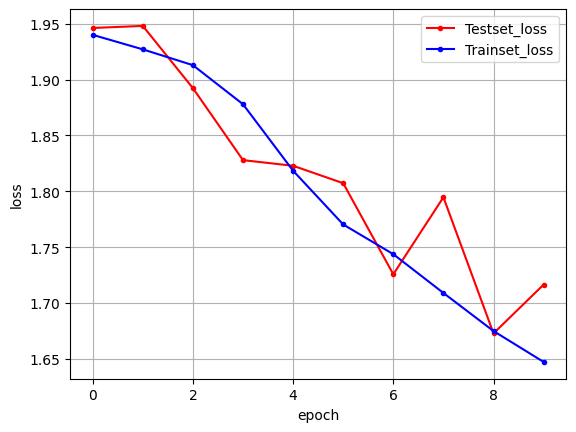

In [ ]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

#### 모델 성능 평가

In [ ]:
class_weight_predictions = class_weight_model.predict(X_test)
class_weight_predicted_labels = np.argmax(class_weight_predictions, axis=1)

class_weight_true_labels = np.argmax(Y_test, axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


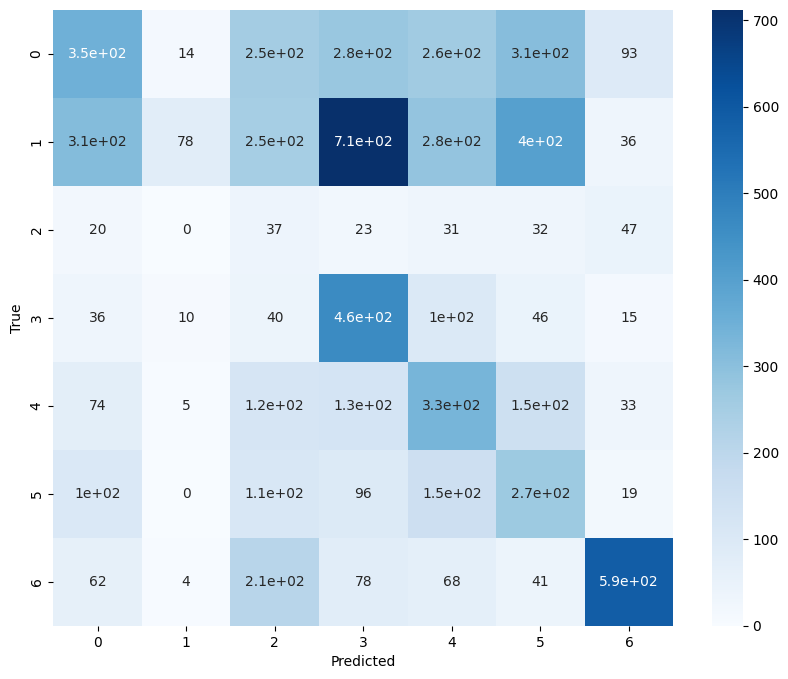

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(class_weight_predicted_labels, class_weight_true_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
from sklearn.metrics import f1_score


# Macro 평균
f1_macro = f1_score(class_weight_true_labels, class_weight_predicted_labels, average='macro')
print(f"class_weight_Macro F1 Score: {f1_macro:.4f}")

# Weighted 평균
f1_weighted = f1_score(class_weight_true_labels, class_weight_predicted_labels, average='weighted')
print(f"class_weight_Weighted F1 Score: {f1_weighted:.4f}")


class_weight_Macro F1 Score: 0.2850
class_weight_Weighted F1 Score: 0.3127


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

cr = classification_report(class_weight_true_labels, class_weight_predicted_labels, target_names = categories)
cr

'              precision    recall  f1-score   support\n\n       angry       0.31      0.15      0.20       958\n     disgust       0.05      0.03      0.04       111\n        fear       0.22      0.08      0.12      1024\n       happy       0.44      0.59      0.50      1774\n     neutral       0.30      0.33      0.31      1233\n         sad       0.33      0.34      0.33      1247\n    surprise       0.49      0.76      0.59       831\n\n    accuracy                           0.38      7178\n   macro avg       0.31      0.33      0.30      7178\nweighted avg       0.35      0.38      0.35      7178\n'

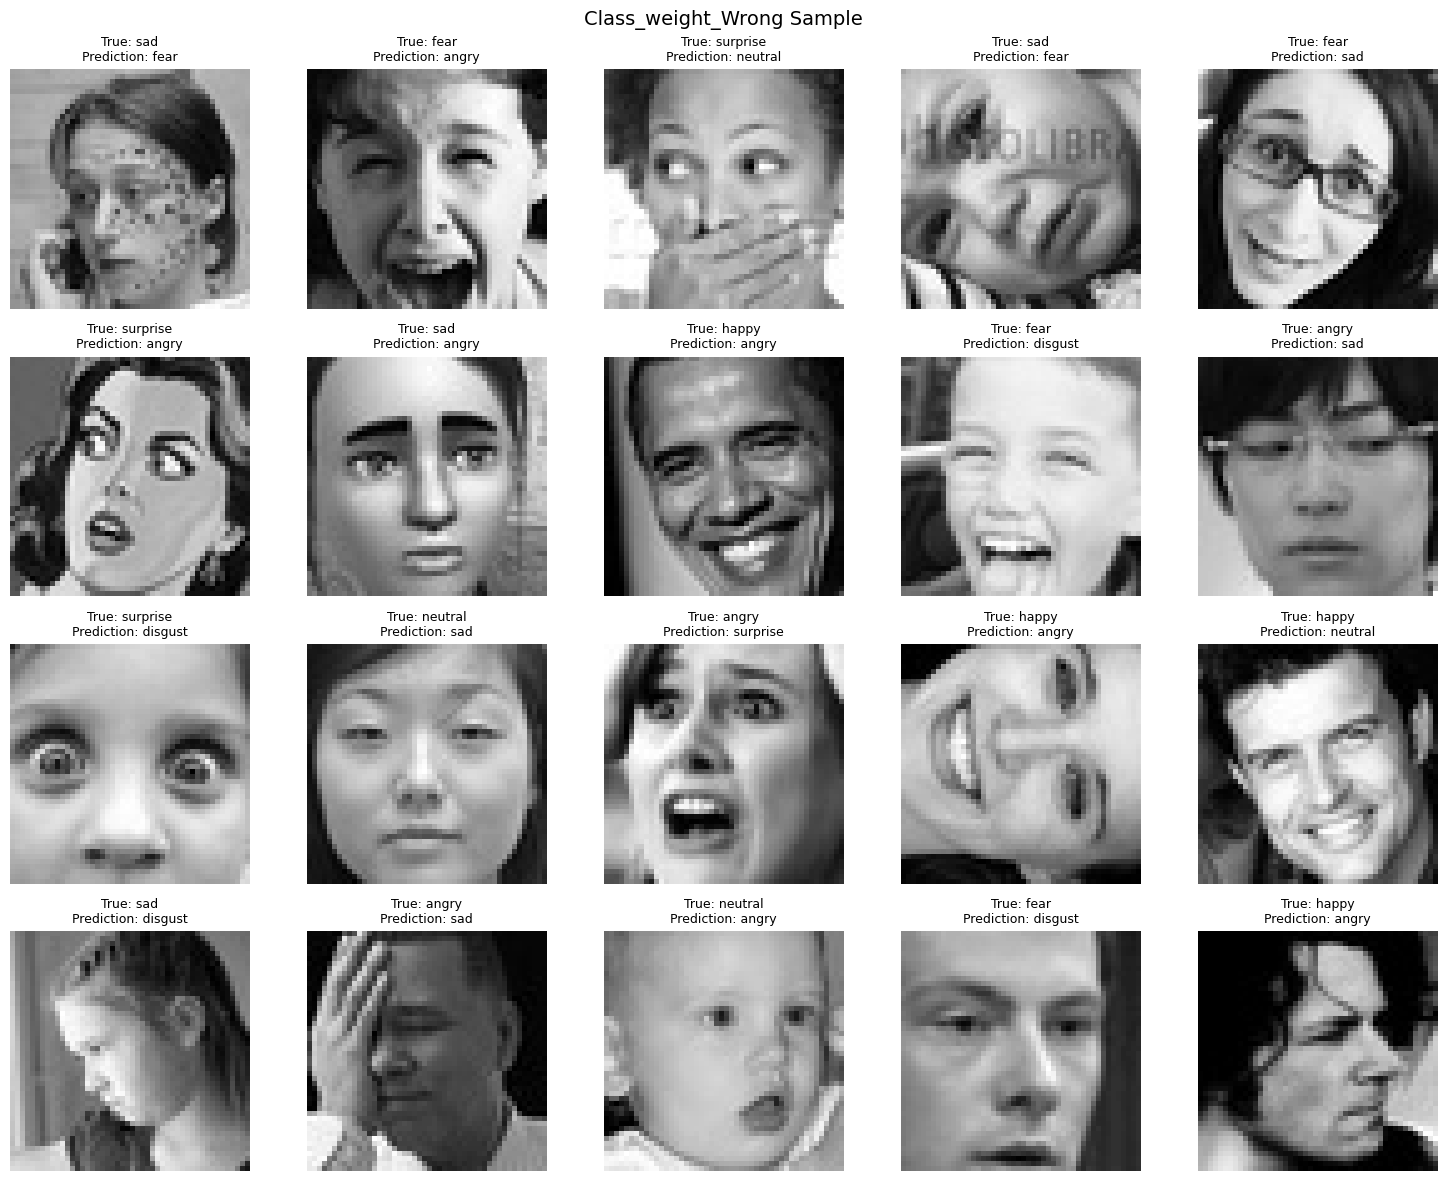

In [ ]:
emotion_labels = categories

# 틀린 인덱스 추출
wrong_idx = np.where(class_weight_predicted_labels != class_weight_true_labels)[0]

# 20개만 랜덤 샘플
sample_idx = np.random.choice(wrong_idx, size=20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i, idx in enumerate(sample_idx):
    axes[i].imshow(X_test[idx].reshape(48, 48), cmap='gray')
    axes[i].set_title(
        f"True: {emotion_labels[class_weight_true_labels[idx]]}\nPrediction: {emotion_labels[class_weight_predicted_labels[idx]]}",
        fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('Class_weight_Wrong Sample', fontsize=14)
plt.tight_layout()
plt.show()

# **최종 모델**

## (1) 직접 가중치 부여하여 모델 학습

In [ ]:
fixed_weight_dict = {0: 1.07,
                     1: 5.0,
                     2: 1.0,
                     3: 0.58,
                     4: 0.83,
                     5: 0.82,
                     6: 1.23}

In [ ]:
# 모델 저장 경로 설정 (구글 드라이브 내 경로)
final_modelpath = "/content/drive/MyDrive/FER2013_CNN_Final.keras"

# 이어하기 : 기존 파일 존재 여부에 따라 결정
if os.path.exists(final_modelpath):
    print("\n[알림] 구글 드라이브에서 기존에 학습된 모델을 불러옵니다.")
    final_model = load_model(final_modelpath)
else:
    print("\n[알림] 기존 모델이 없으므로 새로운 모델을 생성합니다.")
    final_model = Sequential()
    final_model.add(Conv2D(32, kernel_size= (3, 3), padding='same', input_shape=(48, 48, 1), activation='relu'))
    final_model.add(Conv2D(32, (3, 3), activation='relu'))
    final_model.add(MaxPooling2D(pool_size=(2, 2)))
    final_model.add(Dropout(0.25))

    final_model.add(Conv2D(64, (3,3), padding='same', activation = 'relu'))
    final_model.add(Conv2D(64, (3,3), activation='relu'))
    final_model.add(MaxPooling2D(pool_size=(2,2)))
    final_model.add(Dropout(0.25))

    final_model.add(GlobalAveragePooling2D())
    final_model.add(Dense(512, activation='relu'))
    final_model.add(Dropout(0.5))
    final_model.add(Dense(7, activation='softmax'))

    final_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


[알림] 기존 모델이 없으므로 새로운 모델을 생성합니다.


In [ ]:
# 최적화 및 조기 종료 설정
# 여기서도 filepath를 드라이브 경로(modelpath)로 지정.
checkpointer = ModelCheckpoint(filepath=final_modelpath, monitor='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)

# 모델 학습 실행
print("\n학습을 시작합니다...")
history = final_model.fit(X_train, Y_train, validation_split=0.2,
                    epochs=20, batch_size=64, verbose=1,
                    callbacks=[early_stopping_callback, checkpointer],
                    class_weight = fixed_weight_dict #
                )

# 최종 테스트 정확도 출력
print("\n--- 학습 완료 ---")
score = final_model.evaluate(X_test, Y_test, verbose=0)
print("최종 테스트 정확도: %.4f" % score[1])


학습을 시작합니다...
Epoch 1/20
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1662 - loss: 1.7971
Epoch 1: val_loss improved from None to 1.86369, saving model to /content/drive/MyDrive/FER2013_CNN_Final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FER2013_CNN_Final.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.1678 - loss: 1.8007 - val_accuracy: 0.1837 - val_loss: 1.8637
Epoch 2/20
356/359 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.1770 - loss: 1.7873
Epoch 2: val_loss improved from 1.86369 to 1.83423, saving model to /content/drive/MyDrive/FER2013_CNN_Final.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FER2013_CNN_Final.keras
359/359 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.1893 - loss: 1.7749 - val_accuracy: 0.2125 - val_loss: 1.8342
Epoch 3/20
356/359 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.2219 - loss: 1.7720
Epoch 3: val_loss improved from 1.83423 to 1.81114, saving model to /content/drive/MyDrive/FER201

### 학습 과정 모니터링

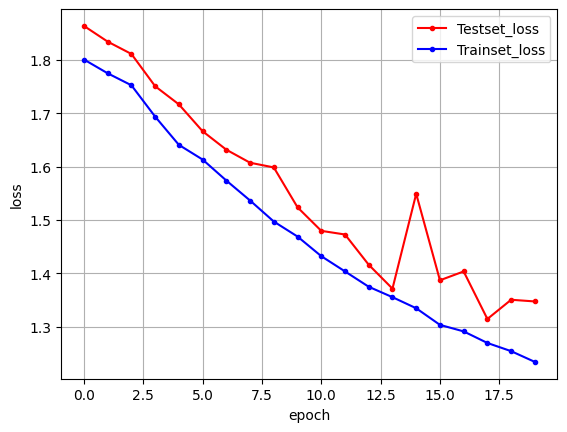

In [ ]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

### 성능 평가

In [ ]:
final_predictions = final_model.predict(X_test)
final_predicted_labels = np.argmax(final_predictions, axis=1)

final_true_labels = np.argmax(Y_test, axis=1)

print(final_predictions)
print(final_predicted_labels)
print(final_true_labels)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
[[5.2474111e-02 4.0597040e-03 1.8126583e-01 ... 5.1858985e-01
  1.8951043e-01 4.1896317e-02]
 [4.0658548e-02 6.6284589e-03 2.8030243e-02 ... 1.9097580e-01
  6.6019595e-02 5.7059070e-03]
 [4.1155063e-02 6.7556871e-04 4.9520168e-02 ... 8.0850673e-01
  8.6662509e-02 5.6615993e-03]
 ...
 [5.9288703e-02 9.1474823e-04 4.0724608e-01 ... 1.7362858e-01
  3.1347421e-01 2.9376842e-02]
 [7.8677662e-02 9.3964906e-03 1.9513117e-01 ... 1.5761670e-01
  4.8966250e-01 7.4999635e-03]
 [7.9703517e-02 5.0676638e-01 1.3828368e-01 ... 2.1568792e-02
  1.5689228e-01 3.7856302e-03]]
[4 3 4 ... 2 5 1]
[4 3 4 ... 5 5 0]


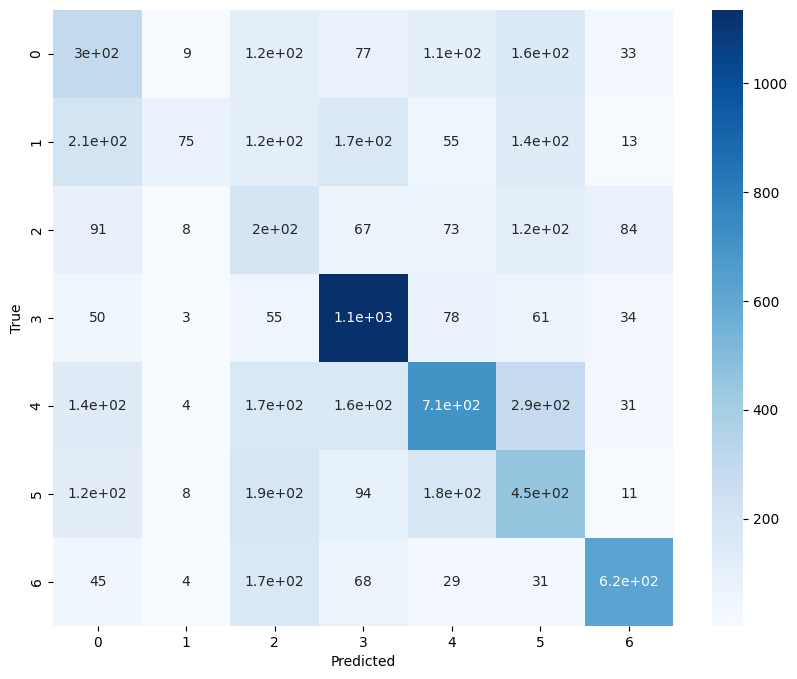

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(final_predicted_labels, final_true_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
from sklearn.metrics import f1_score


# Macro 평균
f1_macro = f1_score(final_true_labels, final_predicted_labels, average='macro')
print(f"final_Macro F1 Score: {f1_macro:.4f}")

# Weighted 평균
f1_weighted = f1_score(final_true_labels, final_predicted_labels, average='weighted')
print(f"final_Weighted F1 Score: {f1_weighted:.4f}")


final_Macro F1 Score: 0.4363
final_Weighted F1 Score: 0.4941


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

cr = classification_report(final_true_labels, final_predicted_labels, target_names = categories)
cr

'              precision    recall  f1-score   support\n\n       angry       0.37      0.31      0.33       958\n     disgust       0.10      0.68      0.17       111\n        fear       0.31      0.19      0.24      1024\n       happy       0.80      0.64      0.71      1774\n     neutral       0.47      0.57      0.51      1233\n         sad       0.43      0.36      0.39      1247\n    surprise       0.64      0.75      0.69       831\n\n    accuracy                           0.49      7178\n   macro avg       0.44      0.50      0.44      7178\nweighted avg       0.52      0.49      0.49      7178\n'

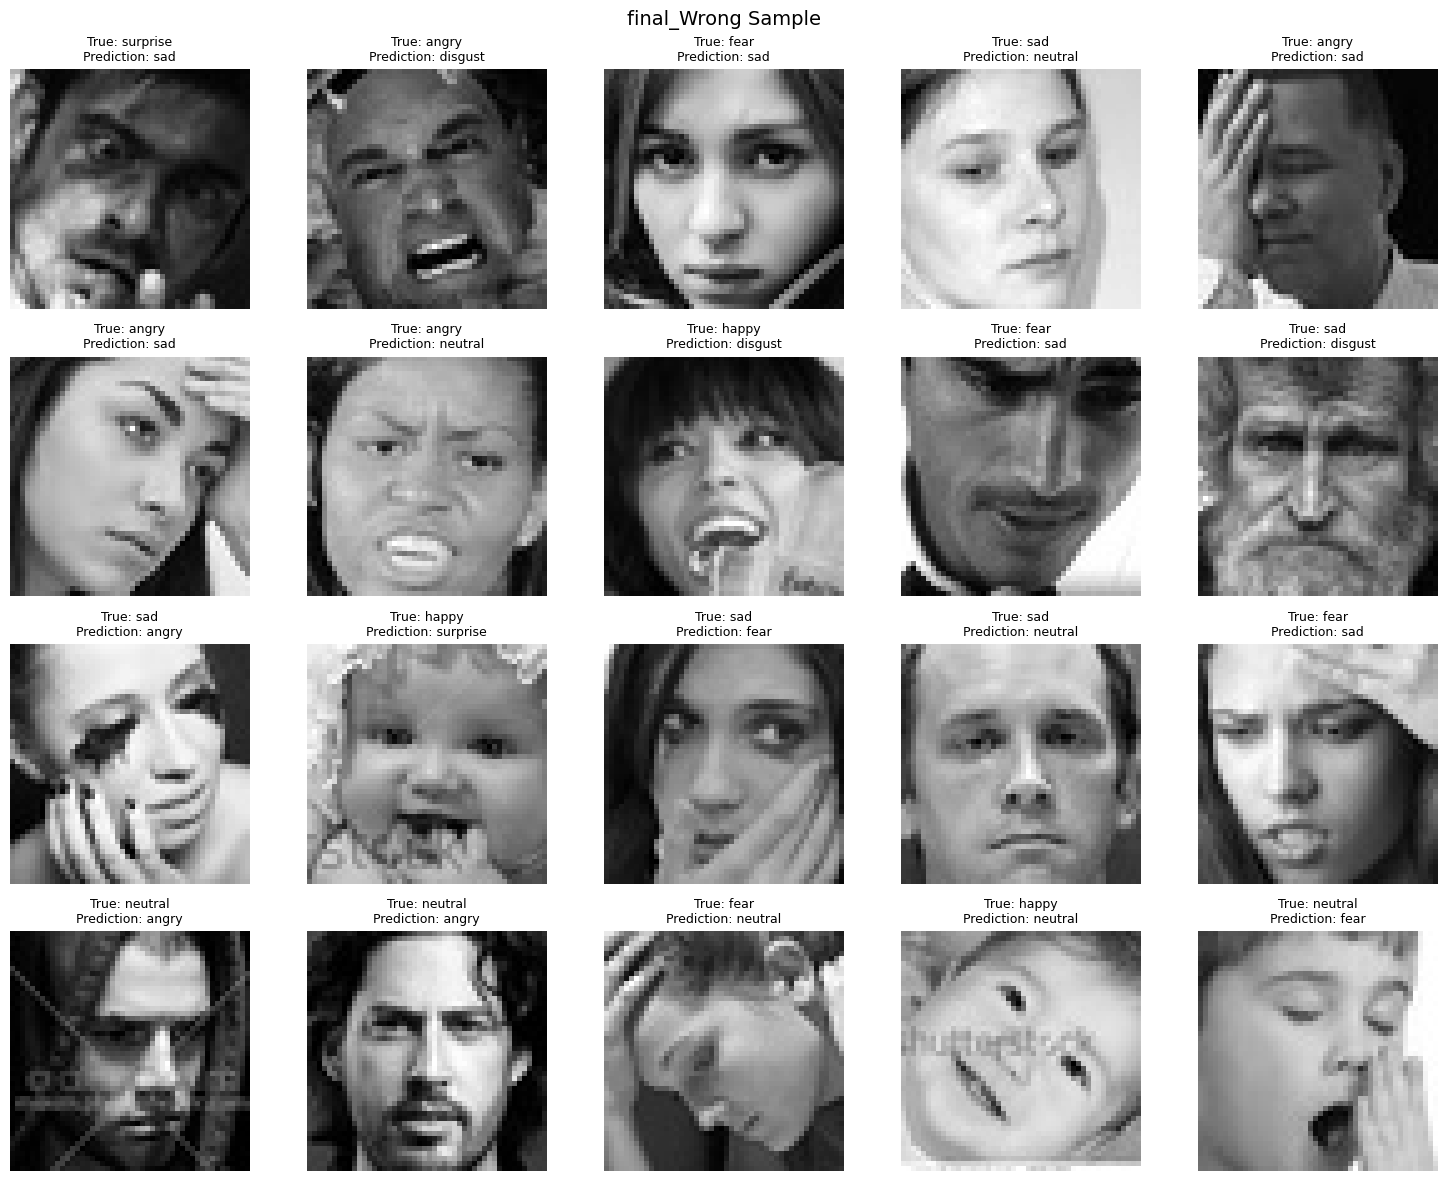

In [ ]:
emotion_labels = categories

# 틀린 인덱스 추출
wrong_idx = np.where(final_predicted_labels != final_true_labels)[0]

# 20개만 랜덤 샘플
sample_idx = np.random.choice(wrong_idx, size=20, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.flatten()

for i, idx in enumerate(sample_idx):
    axes[i].imshow(X_test[idx].reshape(48, 48), cmap='gray')
    axes[i].set_title(
        f"True: {emotion_labels[final_true_labels[idx]]}\nPrediction: {emotion_labels[final_predicted_labels[idx]]}",
        fontsize=9
    )
    axes[i].axis('off')

plt.suptitle('final_Wrong Sample', fontsize=14)
plt.tight_layout()
plt.show()

## (2) Data Augmentation 실시한 최종 모델 학습

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augment_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

disgust_idx = np.where(np.argmax(Y_train, axis=1)==1)[0]
X_disgust = X_train[disgust_idx]
Y_disgust = Y_train[disgust_idx]

aug_iter = augment_datagen.flow(X_disgust, Y_disgust, batch_size=64)
X_disgust_aug, Y_disgust_aug = [], []
for _ in range(10):
    batch_x, batch_y = next(aug_iter)
    X_disgust_aug.append(batch_x)
    Y_disgust_aug.append(batch_y)

X_train_aug = np.concatenate([X_train, np.concatenate(X_disgust_aug)])
Y_train_aug = np.concatenate([Y_train, np.concatenate(Y_disgust_aug)])

In [ ]:
# 최적화 및 조기 종료 설정
# 여기서도 filepath를 드라이브 경로(modelpath)로 지정.
checkpointer = ModelCheckpoint(filepath=final_modelpath, monitor='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=5)

# 모델 학습 실행
print("\n학습을 시작합니다...")
history = final_model.fit(X_train_aug, Y_train_aug, validation_split=0.2,
                    epochs=20, batch_size=64, verbose=1,
                    callbacks=[early_stopping_callback, checkpointer],
                    class_weight = fixed_weight_dict #
                )

# 최종 테스트 정확도 출력
print("\n--- 학습 완료 ---")
score = final_model.evaluate(X_test, Y_test, verbose=0)
print("최종 테스트 정확도: %.4f" % score[1])


학습을 시작합니다...
Epoch 1/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5704 - loss: 1.0100
Epoch 1: val_loss improved from None to 1.37994, saving model to /content/drive/MyDrive/FER2013_CNN_Final.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FER2013_CNN_Final.keras
367/367 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.5655 - loss: 1.0217 - val_accuracy: 0.5215 - val_loss: 1.3799
Epoch 2/20
365/367 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5689 - loss: 1.0180
Epoch 2: val_loss improved from 1.37994 to 1.31052, saving model to /content/drive/MyDrive/FER2013_CNN_Final.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FER2013_CNN_Final.keras
367/367 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.5709 - loss: 1.0205 - val_accuracy: 0.5317 - val_loss: 1.3105
Epoch 3/20
367/367 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5686 - loss: 1.0035
Epoch 3: val_loss did not improve from 1.31052
367/367 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accurac

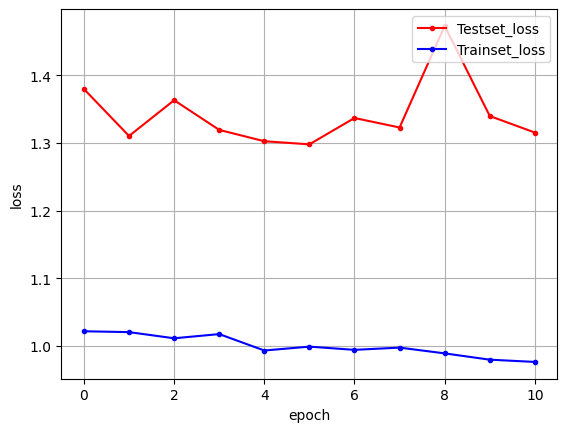

In [ ]:
# 검증셋과 학습셋의 오차를 저장합니다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해 봅니다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c="red", label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c="blue", label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시하겠습니다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

### 성능 평가

In [ ]:
final_predictions = final_model.predict(X_test)
final_predicted_labels = np.argmax(final_predictions, axis=1)

final_true_labels = np.argmax(Y_test, axis=1)

print(final_predictions)
print(final_predicted_labels)
print(final_true_labels)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[2.35126149e-02 1.61918152e-07 1.83234155e-01 ... 3.65440249e-01
  2.00122759e-01 2.16585249e-01]
 [1.87997967e-02 1.53784440e-05 6.77821273e-03 ... 7.34457746e-02
  6.20566942e-02 2.67087878e-03]
 [5.27882315e-02 1.85611853e-07 3.02105639e-02 ... 8.09868574e-01
  1.05045676e-01 9.18223464e-04]
 ...
 [2.47027669e-02 3.20329852e-09 5.39296508e-01 ... 1.17004327e-01
  2.67950237e-01 3.81065123e-02]
 [1.62177622e-01 1.07326472e-04 1.36901051e-01 ... 8.84860158e-02
  5.70848763e-01 5.78490086e-03]
 [1.04132012e-01 4.00112709e-03 2.76557475e-01 ... 4.16801982e-02
  5.14183819e-01 2.51000002e-03]]
[4 3 4 ... 2 5 5]
[4 3 4 ... 5 5 0]


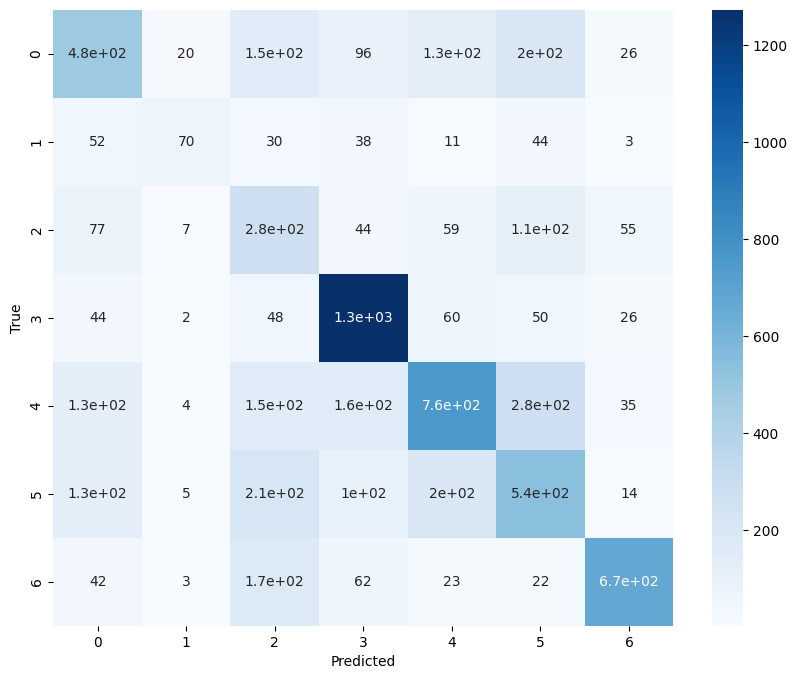

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(final_predicted_labels, final_true_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
from sklearn.metrics import f1_score


# Macro 평균
f1_macro = f1_score(final_true_labels, final_predicted_labels, average='macro')
print(f"final_Macro F1 Score: {f1_macro:.4f}")

# Weighted 평균
f1_weighted = f1_score(final_true_labels, final_predicted_labels, average='weighted')
print(f"final_Weighted F1 Score: {f1_weighted:.4f}")


final_Macro F1 Score: 0.5288
final_Weighted F1 Score: 0.5654


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

cr = classification_report(final_true_labels, final_predicted_labels, target_names = categories)
cr

'              precision    recall  f1-score   support\n\n       angry       0.44      0.50      0.47       958\n     disgust       0.28      0.63      0.39       111\n        fear       0.44      0.27      0.33      1024\n       happy       0.85      0.72      0.78      1774\n     neutral       0.50      0.61      0.55      1233\n         sad       0.45      0.43      0.44      1247\n    surprise       0.68      0.81      0.74       831\n\n    accuracy                           0.57      7178\n   macro avg       0.52      0.57      0.53      7178\nweighted avg       0.58      0.57      0.57      7178\n'